# Profiling de SISMEPRE

Este notebook perfila los archivos de `data/bronze/sismepre`. El foco está en entender la estructura del seguimiento de la meta del impuesto predial, la relación entre tablas y los principales riesgos de calidad antes de futuros cruces analíticos.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use('default')
pd.set_option('display.max_columns', 100)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SISMEPRE_PATH = PROJECT_ROOT / 'data' / 'bronze' / 'sismepre'

expected_files = [
    'rentas_preguntas.csv', 'rentas_estadistica.csv', 'rentas_formulario.csv',
    'rentas_esat_estadistica_atm.csv', 'rentas_respuestas.csv', 'rentas_ano_aplicacion.csv',
    'rentas_entidad_estado.csv', 'rentas_preguntas_diccionario.csv', 'rentas_estadistica_diccionario.csv',
    'rentas_formulario_diccionario.csv', 'rentas_respuestas_diccionario.csv',
    'rentas_entidad_estado_diccionario.csv', 'rentas_ano_aplicacion_diccionario.csv',
    'rentas_esat_estadistica_atm_diccionario.csv'
]

availability_df = pd.DataFrame({
    'filename': expected_files,
    'available_in_bronze': [(SISMEPRE_PATH / file_name).exists() for file_name in expected_files]
})
availability_df

,filename,available_in_bronze
0,rentas_preguntas.csv,True
1,rentas_estadistica.csv,True
2,rentas_formulario.csv,True
3,rentas_esat_estadistica_atm.csv,True
4,rentas_respuestas.csv,True
5,rentas_ano_aplicacion.csv,True
6,rentas_entidad_estado.csv,True
7,rentas_preguntas_diccionario.csv,True
8,rentas_estadistica_diccionario.csv,True
9,rentas_formulario_diccionario.csv,True


## Carga de tablas

Se cargan los CSV principales de SISMEPRE y se organizan en un diccionario de dataframes. Esto permite revisar la estructura de cada tabla y entender qué relaciones existen entre preguntas, formularios, respuestas y estados.

In [2]:
def read_csv_if_exists(file_name: str) -> pd.DataFrame:
    file_path = SISMEPRE_PATH / file_name
    if not file_path.exists():
        return pd.DataFrame()
    frame = pd.read_csv(file_path, encoding='utf-8-sig', low_memory=False)
    frame.columns = [column.replace('﻿', '').strip() for column in frame.columns]
    frame['source_file'] = file_name
    return frame

tables = {
    'preguntas': read_csv_if_exists('rentas_preguntas.csv'),
    'estadistica': read_csv_if_exists('rentas_estadistica.csv'),
    'formulario': read_csv_if_exists('rentas_formulario.csv'),
    'esat_estadistica_atm': read_csv_if_exists('rentas_esat_estadistica_atm.csv'),
    'respuestas': read_csv_if_exists('rentas_respuestas.csv'),
    'ano_aplicacion': read_csv_if_exists('rentas_ano_aplicacion.csv'),
    'entidad_estado': read_csv_if_exists('rentas_entidad_estado.csv')
}

table_shapes = pd.DataFrame([
    {'table': table_name, 'rows': frame.shape[0], 'columns': frame.shape[1]}
    for table_name, frame in tables.items()
])
table_shapes

,table,rows,columns
0,preguntas,696,16
1,estadistica,233,8
2,formulario,94,11
3,esat_estadistica_atm,133172,43
4,respuestas,174210,12
5,ano_aplicacion,26,10
6,entidad_estado,19037,15


## Exploración estructural por tabla

Antes de analizar calidad, conviene revisar una muestra de las tablas principales y confirmar cuáles son sus columnas clave. En SISMEPRE, la tabla central para profiling suele ser `rentas_respuestas.csv`.

In [3]:
display(tables['respuestas'].head())
display(tables['formulario'].head())
display(tables['preguntas'].head())

,RESPUESTA_FECHA,RESPUESTA_TEXTO,PERIODO,RESPUESTA_ID,RESPUESTA_DECIMAL,FORMULARIO_ID,ANO_APLICACION,PREGUNTA_ID,ESTADO_REGISTRO,SEC_EJEC,RESPUESTA_ENTERO,source_file
0,,5,1,1,0.0,1,2022,1,A,300348,0,rentas_respuestas.csv
1,,0,1,2,0.0,1,2022,9,A,300348,0,rentas_respuestas.csv
2,,UNIDAD DE ADMINISTRACION TRIBUTARIA,1,3,0.0,1,2022,10,A,300348,0,rentas_respuestas.csv
3,,0,1,4,0.0,1,2022,11,A,300348,2,rentas_respuestas.csv
4,,N,1,5,0.0,1,2022,12,A,300348,0,rentas_respuestas.csv


,SUB_TITULO,ANO_APLICACION,ORDEN_FORMULARIO,TIPO_FORMULARIO,ESTADO_REGISTRO,CLASIFICACION,ABREVIATURA,TITULO,PERIODO,FORMULARIO_ID,source_file
0,,2021,1,E,,A|B|C|D|E,3A,2A. INFORMACIÓN SOBRE LA EMISIÓN INICIAL TOTAL...,1,6,rentas_formulario.csv
1,,2021,2,E,,A|B|C|D|E,3B,2B. INFORMACIÓN SOBRE LA RECAUDACIÓN DE IMPUES...,1,7,rentas_formulario.csv
2,,2021,3,E,,A|B|C|D|E,3C,2C. INFORMACIÓN SOBRE SALDOS POR COBRAR DEL MO...,1,8,rentas_formulario.csv
3,,2023,1,E,,A|B|C|D|E,3A,3A. INFORMACIÓN SOBRE LA EMISIÓN INICIAL TOTAL...,1,6,rentas_formulario.csv
4,,2023,2,E,,A|B|C|D|E,3B,3B. INFORMACIÓN SOBRE LA RECAUDACIÓN DE IMPUES...,1,7,rentas_formulario.csv


,ANO_APLICACION,PERIODO,FORMULARIO_ID,PREGUNTA_ID,PREGUNTA_PADRE_ID,ORDEN_PREGUNTA,DESCRIPCION,OBJETO_ACTIVO,TIPO_CUESTIONARIO_ID,RESPUESTA,RANGO_INI,RANGO_FIN,TEXTO_APOYO,TEXTO_LECTURA,ESTADO_REGISTRO,source_file
0,2020,1,2,65,0,34,"34. Producto de la fiscalización tributaria, l...",1,11,,0,999999999999999,<Ingresar monto>,Pregunta 34: Es un campo numérico. Usar separa...,A,rentas_preguntas.csv
1,2020,1,2,66,0,35,35. Número de predios fiscalizados:,1,1,,0,999999999,<Ingresar cantidad>,Pregunta 35: Es un campo numérico. Usar separa...,A,rentas_preguntas.csv
2,2020,1,2,67,0,36,36. Área detectada producto de la fiscalizació...,1,0,,,,,Pregunta 36a: Es un campo numérico. Usar separ...,A,rentas_preguntas.csv
3,2020,1,2,68,67,36001,36a. Terreno (m2),1,11,,0,999999999,<Consignar área en m2>,,A,rentas_preguntas.csv
4,2020,1,2,69,67,36002,36b. Construcciones (m2),1,11,,0,999999999,<Consignar área en m2>,,A,rentas_preguntas.csv


## Relaciones entre tablas

En esta parte se estandarizan algunos campos clave para poder revisar relaciones entre respuestas, preguntas y formularios. Esto ayuda a evaluar integridad referencial incluso dentro de Bronze.

In [4]:
respuestas_df = tables['respuestas'].copy()
preguntas_df = tables['preguntas'].copy()
formulario_df = tables['formulario'].copy()
ano_df = tables['ano_aplicacion'].copy()
entidad_estado_df = tables['entidad_estado'].copy()

for frame, columns in [
    (respuestas_df, ['RESPUESTA_ID', 'PREGUNTA_ID', 'FORMULARIO_ID', 'ANO_APLICACION', 'PERIODO', 'SEC_EJEC']),
    (preguntas_df, ['PREGUNTA_ID', 'ANO_APLICACION', 'PERIODO']),
    (formulario_df, ['FORMULARIO_ID', 'ANO_APLICACION', 'PERIODO']),
    (ano_df, ['ANO_APLICACION']),
    (entidad_estado_df, ['ANO_APLICACION', 'PERIODO', 'SEC_EJEC'])
]:
    for column in columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(frame[column], errors='coerce')

respuestas_df[['RESPUESTA_ID', 'PREGUNTA_ID', 'FORMULARIO_ID', 'ANO_APLICACION', 'PERIODO', 'SEC_EJEC']].head()

,RESPUESTA_ID,PREGUNTA_ID,FORMULARIO_ID,ANO_APLICACION,PERIODO,SEC_EJEC
0,1,1,1,2022,1,300348
1,2,9,1,2022,1,300348
2,3,10,1,2022,1,300348
3,4,11,1,2022,1,300348
4,5,12,1,2022,1,300348


## Profiling descriptivo

Aquí se resumen los principales patrones de la fuente: cobertura temporal, volumen por municipalidad, formularios más usados y preguntas con más respuestas registradas.

,ANO_APLICACION,records
0,2022,30600
1,2023,48024
2,2024,74336
3,2025,21250


,PERIODO,records
0,1,30600
1,2,143610


,SEC_EJEC,records
147,300440,468
462,301172,393
443,301133,393
248,300740,393
466,301176,393
33,300166,393
34,300171,393
64,300303,393
115,300381,393
812,301757,393


,PREGUNTA_ID,records
0,1,1836
58,66,1836
33,41,1836
34,42,1836
35,43,1836
40,48,1836
41,49,1836
45,53,1836
46,54,1836
51,59,1836


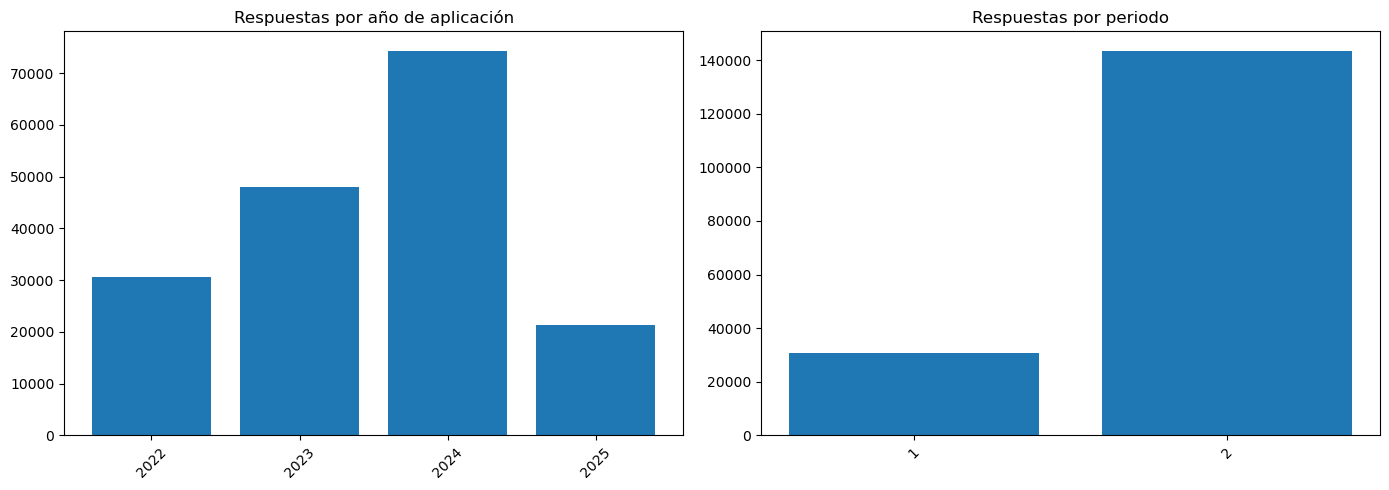

In [5]:
responses_by_year = respuestas_df.groupby('ANO_APLICACION').size().reset_index(name='records').sort_values('ANO_APLICACION')
responses_by_period = respuestas_df.groupby('PERIODO').size().reset_index(name='records').sort_values('PERIODO')
responses_by_muni = respuestas_df.groupby('SEC_EJEC').size().reset_index(name='records').sort_values('records', ascending=False).head(10)
responses_by_question = respuestas_df.groupby('PREGUNTA_ID').size().reset_index(name='records').sort_values('records', ascending=False).head(10)

display(responses_by_year)
display(responses_by_period)
display(responses_by_muni)
display(responses_by_question)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(responses_by_year['ANO_APLICACION'].astype(str), responses_by_year['records'])
axes[0].set_title('Respuestas por año de aplicación')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(responses_by_period['PERIODO'].astype(str), responses_by_period['records'])
axes[1].set_title('Respuestas por periodo')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Calidad de datos - 8 dimensiones

**A partir de esta sección comienza formalmente la evaluación de calidad de datos para SISMEPRE.**

La evaluación se concentra en la tabla de respuestas y se complementa con validaciones de integridad frente a preguntas, formularios y tablas de apoyo.

In [6]:
core_columns = ['RESPUESTA_ID', 'PREGUNTA_ID', 'FORMULARIO_ID', 'ANO_APLICACION', 'PERIODO', 'SEC_EJEC']
missing_core_ratio = respuestas_df[core_columns].isna().mean().mean()

duplicate_ratio = respuestas_df.duplicated(subset=['RESPUESTA_ID']).mean()

valid_year_ratio = respuestas_df['ANO_APLICACION'].between(2012, 2026).mean()
valid_period_ratio = respuestas_df['PERIODO'].between(1, 12).mean()
valid_status_ratio = respuestas_df['ESTADO_REGISTRO'].fillna('').isin(['A', 'I', '']).mean() if 'ESTADO_REGISTRO' in respuestas_df.columns else np.nan
validez_ratio = np.nanmean([valid_year_ratio, valid_period_ratio, valid_status_ratio])

question_keys = set(pd.to_numeric(preguntas_df['PREGUNTA_ID'], errors='coerce').dropna().astype(int).tolist()) if 'PREGUNTA_ID' in preguntas_df.columns else set()
form_keys = set(pd.to_numeric(formulario_df['FORMULARIO_ID'], errors='coerce').dropna().astype(int).tolist()) if 'FORMULARIO_ID' in formulario_df.columns else set()
consistency_question_ratio = respuestas_df['PREGUNTA_ID'].dropna().astype(int).isin(question_keys).mean() if question_keys else np.nan
consistency_form_ratio = respuestas_df['FORMULARIO_ID'].dropna().astype(int).isin(form_keys).mean() if form_keys else np.nan
consistency_ratio = np.nanmean([consistency_question_ratio, consistency_form_ratio])

exact_entero_ratio = pd.to_numeric(respuestas_df['RESPUESTA_ENTERO'], errors='coerce').notna().mean() if 'RESPUESTA_ENTERO' in respuestas_df.columns else np.nan
exact_decimal_ratio = pd.to_numeric(respuestas_df['RESPUESTA_DECIMAL'], errors='coerce').notna().mean() if 'RESPUESTA_DECIMAL' in respuestas_df.columns else np.nan
exactitud_ratio = np.nanmean([exact_entero_ratio, exact_decimal_ratio])

integrity_ratio = respuestas_df[['SEC_EJEC', 'FORMULARIO_ID', 'PREGUNTA_ID']].notna().all(axis=1).mean()

expected_years = set(respuestas_df['ANO_APLICACION'].dropna().astype(int).unique())
actualidad_ratio = len(expected_years) / max(len(expected_years), 1)

trazabilidad_ratio = respuestas_df['source_file'].notna().mean()

quality_summary = pd.DataFrame([
    {'dimension': 'Completitud', 'metric': '1 - promedio de nulos en columnas clave', 'score': round(1 - missing_core_ratio, 4)},
    {'dimension': 'Unicidad', 'metric': '1 - proporción de duplicados de RESPUESTA_ID', 'score': round(1 - duplicate_ratio, 4)},
    {'dimension': 'Validez', 'metric': 'reglas de año, periodo y estado', 'score': round(validez_ratio, 4)},
    {'dimension': 'Consistencia', 'metric': 'existencia de PREGUNTA_ID y FORMULARIO_ID en sus catálogos', 'score': round(consistency_ratio, 4)},
    {'dimension': 'Exactitud', 'metric': 'capacidad de parsear respuestas numéricas', 'score': round(exactitud_ratio, 4)},
    {'dimension': 'Integridad', 'metric': 'presencia conjunta de SEC_EJEC, FORMULARIO_ID y PREGUNTA_ID', 'score': round(integrity_ratio, 4)},
    {'dimension': 'Actualidad', 'metric': 'años observados en la tabla principal', 'score': round(actualidad_ratio, 4)},
    {'dimension': 'Trazabilidad', 'metric': 'presencia de source_file', 'score': round(trazabilidad_ratio, 4)}
])

quality_summary

,dimension,metric,score
0,Completitud,1 - promedio de nulos en columnas clave,1.0000
1,Unicidad,1 - proporción de duplicados de RESPUESTA_ID,0.0011
2,Validez,"reglas de año, periodo y estado",1.0000
3,Consistencia,existencia de PREGUNTA_ID y FORMULARIO_ID en s...,1.0000
4,Exactitud,capacidad de parsear respuestas numéricas,1.0000
5,Integridad,"presencia conjunta de SEC_EJEC, FORMULARIO_ID ...",1.0000
6,Actualidad,años observados en la tabla principal,1.0000
7,Trazabilidad,presencia de source_file,1.0000


## Hallazgos y conclusiones

Además de la calidad de la tabla principal, conviene dejar documentada la incidencia de uno de los diccionarios que no se pudo aterrizar desde la API. Esto no invalida el pipeline, pero sí debe quedar explicado en la defensa del trabajo.

In [7]:
missing_expected = availability_df.loc[~availability_df['available_in_bronze'], 'filename'].tolist()
findings = [
    f'- La tabla principal de respuestas contiene {len(respuestas_df):,} filas.'.replace(',', '.'),
    f'- Las tablas disponibles en Bronze son {int(availability_df["available_in_bronze"].sum())} de {len(availability_df)} esperadas.',
    f'- Los archivos faltantes son: {missing_expected if missing_expected else "ninguno"}.',
    f'- La dimensión con menor score en esta evaluación es: {quality_summary.sort_values("score").iloc[0]["dimension"]}.'
]
display(Markdown('\n'.join(findings)))

- La tabla principal de respuestas contiene 174.210 filas.
- Las tablas disponibles en Bronze son 13 de 14 esperadas.
- Los archivos faltantes son: ['rentas_entidad_estado_diccionario.csv'].
- La dimensión con menor score en esta evaluación es: Unicidad.